
# Quantum Circuits, Entangling Gates & the Walsh–Hadamard Transform

**Faculty Development Programme — Quantum Computing**
*IIT Roorkee, Department of Electronics & Communication Engineering*

---

### Where this notebook sits in the course structure

Double-Slit → Stern–Gerlach cascades → Postulates & bra-ket algebra → Bloch sphere & density matrices →
Purity, coherence & entanglement → Noise channels & information measures → **Gate zoo** → **→ this notebook →** → Bell/CHSH → Teleportation

This notebook is the *synthesis* module: everything learned about single-qubit gates (Notebook: Quantum
Gates) is now assembled into multi-qubit **circuits**, and we introduce the two genuinely new ingredients
needed to go beyond single qubits — **entangling gates** and the **Walsh–Hadamard Transform (WHT)**.

### Learning objectives

By the end of this notebook, learners will be able to:

1. Explain what a quantum circuit *is* mathematically (an ordered product of unitaries, read left-to-right,
   multiplied right-to-left) and draw one.
2. Derive the action of the Hadamard gate as the $z \leftrightarrow x$ Stern–Gerlach basis change, and
   generalise it to the $n$-qubit **Walsh–Hadamard Transform** $H^{\otimes n}$.
3. Distinguish **local** (single-qubit, separability-preserving) operations from **entangling** two-qubit
   gates (CNOT, CZ, SWAP) and the three-qubit Toffoli gate.
4. Build a Bell state and a GHZ state from scratch and *verify* entanglement using the reduced-density-matrix
   purity test already built in the earlier notebooks.
5. Write and run a minimal statevector circuit simulator — gates as matrices, wires as tensor factors,
   measurement as Born-rule sampling — entirely in NumPy.

### Central thesis (unchanged from Notebook 1)

> *Indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*

A quantum circuit is nothing but a controlled way of arranging *which* alternatives are indistinguishable,
and for how long, before we look.



## 0. Setup

We reuse the toolkit built in earlier notebooks (`qubit_state`, `bloch_vector`, `rho_from_bloch`,
`bloch_from_rho`, `purity`, `born_probs`, `apply_kraus`) unchanged, and add the single-qubit gate
constants from the Quantum Gates notebook. No SciPy, Qiskit, or PennyLane — pure NumPy + Matplotlib,
consistent with the rest of the series. `ipywidgets` is used for one optional interactive cell, wrapped
in a `try/except` static-fallback so the notebook still converts headlessly (the same fix used since
Notebook 2).


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

try:
    from ipywidgets import interact, FloatSlider
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

print("Setup complete. ipywidgets available:", HAVE_WIDGETS)


Setup complete. ipywidgets available: True


In [2]:

# ---------------------------------------------------------------------------
# Reusable toolkit (carried forward unchanged from earlier notebooks)
# ---------------------------------------------------------------------------

def qubit_state(theta, phi):
    '''Pure single-qubit state on the Bloch sphere: |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>.'''
    return np.array([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)], dtype=complex)

def bloch_vector(psi):
    '''Bloch vector (x, y, z) of a pure single-qubit state vector psi.'''
    rho = np.outer(psi, psi.conj())
    return bloch_from_rho(rho)

def rho_from_bloch(r):
    '''Density matrix from a Bloch vector r = (x, y, z).'''
    x, y, z = r
    I = np.eye(2, dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    return 0.5 * (I + x * X + y * Y + z * Z)

def bloch_from_rho(rho):
    '''Bloch vector (x, y, z) from a single-qubit density matrix.'''
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    x = np.real(np.trace(rho @ X))
    y = np.real(np.trace(rho @ Y))
    z = np.real(np.trace(rho @ Z))
    return np.array([x, y, z])

def purity(rho):
    '''Tr(rho^2). 1 for pure states, < 1 for mixed states.'''
    return np.real(np.trace(rho @ rho))

def born_probs(psi):
    '''Born-rule outcome probabilities |amplitude|^2 for a statevector psi.'''
    return np.abs(psi) ** 2

def apply_kraus(rho, kraus_list):
    '''Apply a Kraus channel: rho -> sum_k K_k rho K_k^dagger.'''
    return sum(K @ rho @ K.conj().T for K in kraus_list)

# Single-qubit gate zoo (from the Quantum Gates notebook)
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
H  = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S  = np.array([[1, 0], [0, 1j]], dtype=complex)
T  = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

print("Toolkit loaded: qubit_state, bloch_vector, rho_from_bloch, bloch_from_rho,")
print("                purity, born_probs, apply_kraus, and gates I,X,Y,Z,H,S,T")


Toolkit loaded: qubit_state, bloch_vector, rho_from_bloch, bloch_from_rho,
                purity, born_probs, apply_kraus, and gates I,X,Y,Z,H,S,T



## 1. What Is a Quantum Circuit?

**Physical anchor.** A Stern–Gerlach cascade — magnet, then magnet, then magnet — *is already a quantum
circuit*: each magnet is a basis-dependent filter/rotation, and stacking magnets in sequence composes
their effects. A quantum circuit generalises this to arbitrary unitary "magnets" (gates) acting on
arbitrary numbers of qubits ("wires"), with a measurement at the end standing in for the final screen.

**Formal definition.** A quantum circuit on $n$ qubits is:

$$|\psi_{\text{out}}\rangle = U_k \, U_{k-1} \cdots U_2 \, U_1 \, |\psi_{\text{in}}\rangle$$

- **Wires** = qubits; the state lives in $(\mathbb{C}^2)^{\otimes n}$, dimension $2^n$.
- **Boxes on a wire** = unitary gates. Time flows **left to right** on the circuit diagram, but because
  matrices act on kets by left-multiplication, the *matrix product is written right to left*
  ($U_1$ applied first, appears rightmost).
- **Gates on parallel wires with nothing shared** = **tensor product**. E.g. an $H$ on qubit 1 and
  an $X$ on qubit 2, applied simultaneously, is $H \otimes X$.
- **Gates spanning multiple wires** (CNOT, CZ, Toffoli, …) = genuinely joint unitaries that cannot be
  written as a tensor product of per-wire unitaries. These are precisely the **entangling gates** —
  the subject of §4.
- **Measurement** = Born-rule sampling from $|\langle x|\psi_{\text{out}}\rangle|^2$, collapsing the
  state (Notebook 2, Postulate 3).

A circuit is therefore completely specified by (a) the list of gates, (b) which wire(s) each acts on,
and (c) the order. Everything else — interference, entanglement, algorithms — is what you get by
choosing that list cleverly.

**Potential Misconception.** "Circuit diagrams are just flowcharts" — no. Unlike a classical flowchart,
there is no branching or copying: gates are *always* invertible unitaries (no-cloning, Notebook 2), and
every wire persists through the whole diagram whether or not a gate acts on it that step (an implicit
identity $I$ is present).


In [20]:

def kron_list(mats):
    '''Tensor (Kronecker) product of a list of matrices/vectors, left to right.'''
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def embed_1q_gate(gate, target, n_qubits):
    '''Embed a single-qubit gate acting on `target` into the full n-qubit Hilbert space,
    with identity on every other wire. Qubit 0 is the leftmost wire (big-endian).'''
    ops = [I2] * n_qubits
    ops[target] = gate
    return kron_list(ops)

def ket(bitstring):
    '''Computational basis state from a bitstring, e.g. ket('010') -> |010>.'''
    single = {'0': np.array([1, 0], dtype=complex), '1': np.array([0, 1], dtype=complex)}
    return kron_list([single[b] for b in bitstring])

# Sanity check: H on qubit 0 of a 2-qubit register, applied to |00>
n = 2
psi = ket('00')
U = embed_1q_gate(H, target=0, n_qubits=n)
psi_out = U @ psi
print("H (x) I applied to |00>:")
print(psi_out.round(3), "  <- equal superposition on wire 0, wire 1 untouched, as expected")


H (x) I applied to |00>:
[0.707+0.j 0.   +0.j 0.707+0.j 0.   +0.j]   <- equal superposition on wire 0, wire 1 untouched, as expected



## 2. The Hadamard Transform (single qubit)

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle, \qquad
H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle$$

**This is precisely the $z \leftrightarrow x$ Stern–Gerlach basis change** from Notebook 1: $|0\rangle,
|1\rangle$ are the $S_z$ eigenstates; $|+\rangle, |-\rangle$ are the $S_x$ eigenstates. Sending an atom
through an $H$ "magnet" and then measuring is exactly re-orienting the SG apparatus by 90°. On the Bloch
sphere, $H$ is a $180°$ rotation about the axis $\hat{n} = (\hat{x}+\hat{z})/\sqrt{2}$ — it swaps the
$x$- and $z$-axes and flips $y \to -y$.

$H$ is **self-inverse** ($H^2 = I$) and **unitary** ($H^\dagger H = I$): applying two SG magnets at the
same orientation in a row, with no measurement in between, does nothing — the alternatives recombine
coherently rather than being distinguished. This is the same coherence argument used to explain why an
un-measured SG cascade shows no "which-path" collapse.


In [4]:

# Verify H is unitary and self-inverse
print("H =\n", H.round(3))
print("\nH @ H.conj().T (should be I):\n", (H @ H.conj().T).round(3))
print("\nH @ H (should be I, since H is self-inverse):\n", (H @ H).round(3))

print("\nH|0> =", (H @ ket('0')).round(3), " -> |+>")
print("H|1> =", (H @ ket('1')).round(3), " -> |->")


H =
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]

H @ H.conj().T (should be I):
 [[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]

H @ H (should be I, since H is self-inverse):
 [[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]

H|0> = [0.707+0.j 0.707+0.j]  -> |+>
H|1> = [ 0.707+0.j -0.707+0.j]  -> |->


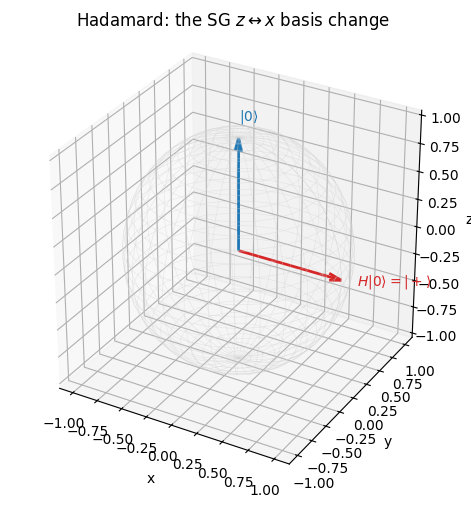

In [21]:

def plot_bloch_sphere(vectors, labels, colors, title):
    '''Minimal 3D Bloch sphere plot for a handful of labelled vectors.'''
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')

    u, v = np.linspace(0, 2 * np.pi, 30), np.linspace(0, np.pi, 30)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='lightgray', linewidth=0.4, alpha=0.5)

    for r, lab, c in zip(vectors, labels, colors):
        ax.quiver(0, 0, 0, *r, color=c, linewidth=2, arrow_length_ratio=0.12)
        ax.text(*(1.15 * np.array(r)), lab, color=c, fontsize=10, weight='bold')

    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_box_aspect([1, 1, 1])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Show H rotating |0> (north pole, +z) to |+> (+x)
psi0 = ket('0')
psiH = H @ psi0
plot_bloch_sphere(
    [bloch_vector(psi0), bloch_vector(psiH)],
    [r'$|0\rangle$', r'$H|0\rangle=|+\rangle$'],
    ['tab:blue', 'tab:red'],
    'Hadamard: the SG $z \\leftrightarrow x$ basis change'
)


In [6]:

# Optional interactive: drag theta/phi and watch H act on an arbitrary Bloch vector
def show_H_action(theta_deg=40.0, phi_deg=30.0):
    theta, phi = np.deg2rad(theta_deg), np.deg2rad(phi_deg)
    psi_in = qubit_state(theta, phi)
    psi_out = H @ psi_in
    plot_bloch_sphere(
        [bloch_vector(psi_in), bloch_vector(psi_out)],
        [r'$|\psi\rangle$', r'$H|\psi\rangle$'],
        ['tab:blue', 'tab:red'],
        f'H acting on theta={theta_deg:.0f} deg, phi={phi_deg:.0f} deg'
    )

if HAVE_WIDGETS:
    try:
        interact(show_H_action,
                 theta_deg=FloatSlider(min=0, max=180, step=5, value=40),
                 phi_deg=FloatSlider(min=0, max=360, step=5, value=30))
    except Exception:
        show_H_action()
else:
    show_H_action()


interactive(children=(FloatSlider(value=40.0, description='theta_deg', max=180.0, step=5.0), FloatSlider(value…


## 3. The Walsh–Hadamard Transform (n qubits)

Applying $H$ to *every* wire simultaneously gives the **Walsh–Hadamard Transform**:

$$H^{\otimes n} = \underbrace{H \otimes H \otimes \cdots \otimes H}_{n \text{ factors}}, \qquad
H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} |x\rangle$$

Starting from all-zeros, a single layer of $n$ parallel Hadamards creates a perfectly **uniform
superposition over all $2^n$ computational basis states** — the standard opening move of almost every
quantum algorithm (Deutsch–Jozsa, Grover, Simon, QFT-based algorithms).

**Matrix structure.** $H^{\otimes n}$ is the classical **Sylvester–Hadamard matrix** of order $2^n$
(up to the $1/\sqrt{2^n}$ normalisation), built recursively:

$$H^{\otimes n} = \frac{1}{\sqrt{2}}\begin{pmatrix} H^{\otimes(n-1)} & H^{\otimes(n-1)} \\
H^{\otimes(n-1)} & -H^{\otimes(n-1)} \end{pmatrix}$$

and its $(x,y)$ entry has the closed form $\left(H^{\otimes n}\right)_{xy} = \frac{1}{\sqrt{2^n}}(-1)^{x\cdot y}$,
where $x \cdot y = \bigoplus_i x_i y_i$ is the bitwise dot product mod 2. Each row is a **Walsh function**
— the same object used classically in Walsh–Fourier analysis and spread-spectrum coding — which is why
Deutsch–Jozsa-style algorithms can be understood as *quantum parallel evaluation of a Walsh–Fourier
transform*.

**Misconception callout.** "The uniform superposition already contains the answer, so we've achieved
exponential speedup for free." No — a superposition over $2^n$ states holding *equal* amplitudes carries
no information until it is shaped by further gates (oracle + interference) and then measured; a
measurement on $H^{\otimes n}|0\rangle^{\otimes n}$ alone just returns a uniformly random $n$-bit string.


In [7]:

def walsh_hadamard(n):
    '''Build H^{(x)n} recursively (Sylvester construction).'''
    Hn = np.array([[1.0]])
    for _ in range(n):
        Hn = (1 / np.sqrt(2)) * np.block([[Hn, Hn], [Hn, -Hn]])
    return Hn

for n in [1, 2, 3]:
    Hn = walsh_hadamard(n)
    Hn_kron = kron_list([H] * n)
    assert np.allclose(Hn, Hn_kron), "Recursive construction must match repeated kron product"
print("Verified: recursive Sylvester construction == H (x) H (x) ... (x) H, for n = 1, 2, 3")


Verified: recursive Sylvester construction == H (x) H (x) ... (x) H, for n = 1, 2, 3


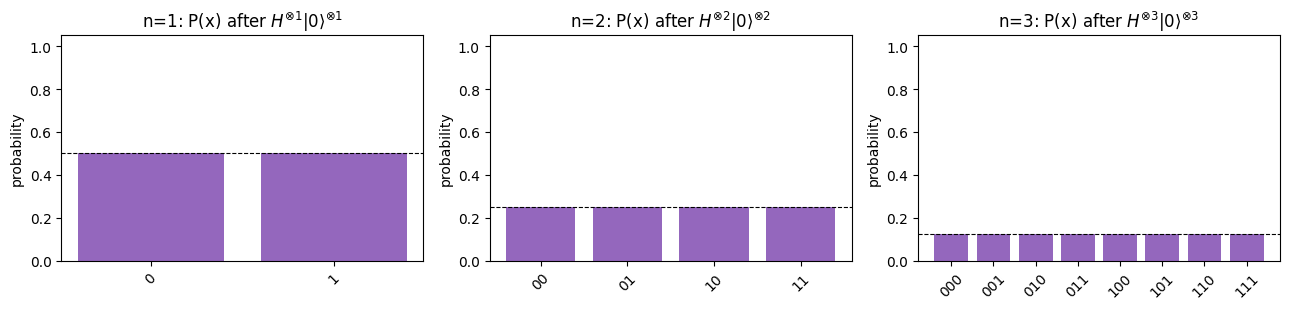

Every outcome has probability exactly 1/2^n -- a perfectly uniform superposition.


In [8]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, n in zip(axes, [1, 2, 3, ][:3]):
    Hn = walsh_hadamard(n)
    psi0 = ket('0' * n)
    psi_uniform = Hn @ psi0
    probs = born_probs(psi_uniform)
    labels = [format(x, f'0{n}b') for x in range(2 ** n)]
    ax.bar(labels, probs, color='tab:purple')
    ax.set_ylim(0, 1.05 / 1)
    ax.axhline(1 / 2 ** n, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'n={n}: P(x) after $H^{{\\otimes {n}}}|0\\rangle^{{\\otimes {n}}}$')
    ax.set_ylabel('probability')
    for lab in ax.get_xticklabels():
        lab.set_rotation(45)
plt.tight_layout()
plt.show()
print("Every outcome has probability exactly 1/2^n -- a perfectly uniform superposition.")


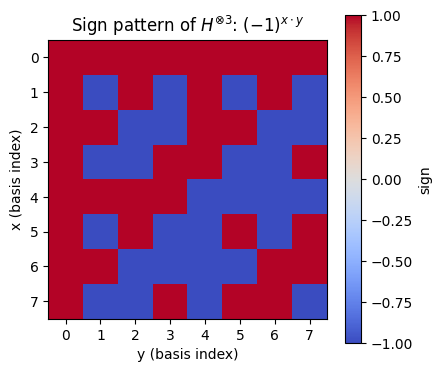

Each row is a discrete Walsh function of x -- the classical spread-spectrum / Walsh-Fourier basis.


In [9]:

# Visualize the Walsh-Hadamard matrix as a sign pattern: entry (x,y) = (-1)^{x.y}/sqrt(2^n)
n = 3
Hn = walsh_hadamard(n)
signs = np.sign(Hn)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(signs, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title(f'Sign pattern of $H^{{\\otimes {n}}}$: $(-1)^{{x\\cdot y}}$')
ax.set_xlabel('y (basis index)'); ax.set_ylabel('x (basis index)')
ax.set_xticks(range(2 ** n)); ax.set_yticks(range(2 ** n))
plt.colorbar(im, label='sign', shrink=0.8)
plt.tight_layout()
plt.show()
print("Each row is a discrete Walsh function of x -- the classical spread-spectrum / Walsh-Fourier basis.")



## 4. Entangling Gates

Everything so far — $H$, $H^{\otimes n}$, any single-qubit gate on any wire — is **local**: it acts as
$U_1 \otimes U_2 \otimes \cdots$, and *local unitaries can never turn a product state into an entangled
one* (Notebook 4). To entangle qubits we need a gate that genuinely couples two (or more) wires and
cannot be factored as a tensor product.

### CNOT (Controlled-NOT)

$$\text{CNOT} = \begin{pmatrix} 1&0&0&0 \\ 0&1&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \end{pmatrix}, \qquad
\text{CNOT}|c,t\rangle = |c,\, t\oplus c\rangle$$

Flips the target qubit **if and only if** the control is $|1\rangle$ — a quantum if-statement acting
coherently on superpositions.

### CZ, SWAP, Toffoli (CCNOT)

- **CZ**: applies a $-1$ phase iff both qubits are $|1\rangle$; symmetric in control/target;
  related to CNOT by $\text{CZ} = (I\otimes H)\,\text{CNOT}\,(I\otimes H)$ — an exercise below.
- **SWAP**: exchanges the states of two wires; equals three CNOTs in sequence (CNOT-SWAP identity).
- **Toffoli (CCNOT)**: three-qubit gate, flips the target iff *both* controls are $|1\rangle$; the
  reversible-classical workhorse (implements AND/NAND reversibly) and a universal classical gate.

### The canonical entangling circuit — the Bell-state recipe

$$|00\rangle \xrightarrow{H \otimes I} \frac{|00\rangle+|10\rangle}{\sqrt2} \xrightarrow{\text{CNOT}}
\frac{|00\rangle+|11\rangle}{\sqrt2} = |\Phi^+\rangle$$

One Hadamard creates *which-path ambiguity* on qubit 0; the CNOT then makes qubit 1's value **depend**
on that ambiguity rather than resolving it — the two qubits become one indivisible interference pattern.
This is the two-qubit generalisation of the SG cascade thread: superposition (H) followed by a
*correlating* interaction (CNOT) is exactly how "indistinguishable alternatives" become shared between
particles.


In [10]:

# Two-qubit and three-qubit entangling gates as explicit matrices
CNOT = np.array([[1,0,0,0],
                  [0,1,0,0],
                  [0,0,0,1],
                  [0,0,1,0]], dtype=complex)

CZ = np.array([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,-1]], dtype=complex)

SWAP = np.array([[1,0,0,0],
                   [0,0,1,0],
                   [0,1,0,0],
                   [0,0,0,1]], dtype=complex)

TOFFOLI = np.eye(8, dtype=complex)
TOFFOLI[[6, 7], :] = TOFFOLI[[7, 6], :]   # swap |110> <-> |111>

for name, U in [('CNOT', CNOT), ('CZ', CZ), ('SWAP', SWAP), ('Toffoli', TOFFOLI)]:
    unitary_ok = np.allclose(U @ U.conj().T, np.eye(U.shape[0]))
    print(f"{name:8s} unitary? {unitary_ok}   shape={U.shape}")


CNOT     unitary? True   shape=(4, 4)
CZ       unitary? True   shape=(4, 4)
SWAP     unitary? True   shape=(4, 4)
Toffoli  unitary? True   shape=(8, 8)


In [11]:

# Build the Bell state |Phi+> = (|00> + |11>)/sqrt(2) from scratch, gate by gate
psi = ket('00')
psi = embed_1q_gate(H, target=0, n_qubits=2) @ psi   # H on qubit 0
psi = CNOT @ psi                                       # CNOT: qubit 0 controls qubit 1

print("Bell state |Phi+> amplitudes for |00>,|01>,|10>,|11>:")
print(psi.round(3))
print("\nBorn-rule probabilities:", born_probs(psi).round(3))


Bell state |Phi+> amplitudes for |00>,|01>,|10>,|11>:
[0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]

Born-rule probabilities: [0.5 0.  0.  0.5]


In [12]:

def reduced_density_matrix(psi, keep, n_qubits):
    '''Partial trace of a pure 2-qubit-register state, keeping only wire `keep` (0 or 1).
    Implemented directly for the 2-qubit case used throughout this notebook.'''
    assert n_qubits == 2, "This helper is specialised to 2 qubits for clarity; see Exercise 3 for n=3."
    M = psi.reshape(2, 2)              # rows = qubit 0 index, cols = qubit 1 index
    if keep == 0:
        rho = M @ M.conj().T
    else:
        rho = M.T @ M.conj()
    return rho

rho_A = reduced_density_matrix(psi, keep=0, n_qubits=2)
rho_B = reduced_density_matrix(psi, keep=1, n_qubits=2)

print("Reduced state of qubit 0 (tracing out qubit 1):\n", rho_A.round(3))
print("Purity of qubit 0's reduced state:", round(purity(rho_A), 3),
      " (1.0 = pure/unentangled, 0.5 = maximally mixed -> maximally entangled)")
print()
print("Reduced state of qubit 1 (tracing out qubit 0):\n", rho_B.round(3))
print("Purity of qubit 1's reduced state:", round(purity(rho_B), 3))
print()
print("Purity == 0.5 on BOTH wires confirms |Phi+> is maximally entangled")
print("(exactly the purity/entanglement diagnostic from the earlier entanglement notebook).")


Reduced state of qubit 0 (tracing out qubit 1):
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Purity of qubit 0's reduced state: 0.5  (1.0 = pure/unentangled, 0.5 = maximally mixed -> maximally entangled)

Reduced state of qubit 1 (tracing out qubit 0):
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Purity of qubit 1's reduced state: 0.5

Purity == 0.5 on BOTH wires confirms |Phi+> is maximally entangled
(exactly the purity/entanglement diagnostic from the earlier entanglement notebook).


In [13]:

# GHZ state: the 3-qubit generalisation, (|000> + |111>)/sqrt(2)
n = 3
psi3 = ket('000')
psi3 = embed_1q_gate(H, target=0, n_qubits=n) @ psi3

def embed_2q_gate(gate2, control, target, n_qubits):
    '''Embed a 2-qubit gate (already written in the {control,target} pair's own 4-dim basis)
    acting on (control, target) into the full n-qubit space. Restricted here to n=3 with an
    explicit basis-permutation approach, kept intentionally simple/readable for teaching.'''
    dim = 2 ** n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    for basis_idx in range(dim):
        bits = list(format(basis_idx, f'0{n_qubits}b'))
        c, t = bits[control], bits[target]
        sub_in = int(c + t, 2)
        for sub_out in range(4):
            amp = gate2[sub_out, sub_in]
            if amp == 0:
                continue
            out_bits = bits.copy()
            out_c, out_t = format(sub_out, '02b')
            out_bits[control], out_bits[target] = out_c, out_t
            out_idx = int(''.join(out_bits), 2)
            U[out_idx, basis_idx] += amp
    return U

CNOT_01_of3 = embed_2q_gate(CNOT, control=0, target=1, n_qubits=3)
CNOT_02_of3 = embed_2q_gate(CNOT, control=0, target=2, n_qubits=3)

psi3 = CNOT_01_of3 @ psi3
psi3 = CNOT_02_of3 @ psi3

print("GHZ state amplitudes (basis order 000..111):")
print(psi3.round(3))
print("\nNonzero only on |000> and |111>, each with probability",
      round(np.abs(psi3[0])**2, 3), "and", round(np.abs(psi3[-1])**2, 3))


GHZ state amplitudes (basis order 000..111):
[0.707+0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j 0.   +0.j
 0.707+0.j]

Nonzero only on |000> and |111>, each with probability 0.5 and 0.5



### Entangling power: a quick witness sweep

The circuit $H$-then-CNOT entangles maximally. What if we replace the CNOT by a *partial* two-qubit
gate that interpolates between "do nothing" and "full CNOT"? We should see the reduced-state purity
sweep continuously from $1.0$ (product state) down to $0.5$ (maximal entanglement) and — for this
particular family — back up again, tracing out an entanglement "breathing" curve.


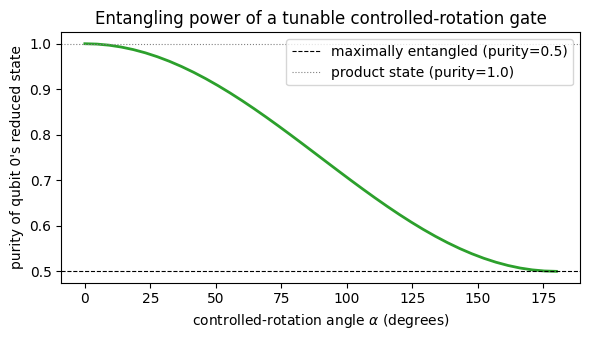

alpha=0 -> local gate, no entanglement. alpha=180 deg -> full CNOT-like gate, maximal entanglement.


In [14]:

def controlled_phase_family(alpha):
    '''A tunable 2-qubit entangling gate: controlled rotation by angle alpha on the target,
    interpolating between I (alpha=0, no entanglement) and a maximally-entangling gate.'''
    c, s = np.cos(alpha / 2), np.sin(alpha / 2)
    U = np.eye(4, dtype=complex)
    # Acts only in the {|10>,|11>} subspace, rotating the target conditioned on control=1
    U[2, 2], U[2, 3] = c, -1j * s
    U[3, 2], U[3, 3] = -1j * s, c
    return U

alphas = np.linspace(0, np.pi, 40)
purities = []
for a in alphas:
    psi = embed_1q_gate(H, target=0, n_qubits=2) @ ket('00')
    psi = controlled_phase_family(a) @ psi
    rho0 = reduced_density_matrix(psi, keep=0, n_qubits=2)
    purities.append(purity(rho0))

plt.figure(figsize=(6, 3.5))
plt.plot(np.rad2deg(alphas), purities, color='tab:green', linewidth=2)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='maximally entangled (purity=0.5)')
plt.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, label='product state (purity=1.0)')
plt.xlabel(r'controlled-rotation angle $\alpha$ (degrees)')
plt.ylabel("purity of qubit 0's reduced state")
plt.title('Entangling power of a tunable controlled-rotation gate')
plt.legend()
plt.tight_layout()
plt.show()
print("alpha=0 -> local gate, no entanglement. alpha=180 deg -> full CNOT-like gate, maximal entanglement.")



## 5. Circuit Composition, Simulation & Measurement

We now package everything above into a minimal, from-scratch **statevector simulator**: a `QuantumCircuit`
class that accumulates gates and applies them in order, plus a lightweight circuit-diagram drawer so
learners can *see* what they built before running it. This mirrors (in miniature) what Qiskit/PennyLane
do internally — useful scaffolding before the dedicated framework notebooks.


In [15]:

class QuantumCircuit:
    '''A minimal statevector circuit simulator: gates as matrices, wires as tensor factors.'''

    def __init__(self, n_qubits):
        self.n = n_qubits
        self.state = ket('0' * n_qubits)
        self.ops = []          # log of (gate_name, wires) for drawing/inspection

    def h(self, wire):
        self.state = embed_1q_gate(H, wire, self.n) @ self.state
        self.ops.append(('H', [wire]))
        return self

    def x(self, wire):
        self.state = embed_1q_gate(X, wire, self.n) @ self.state
        self.ops.append(('X', [wire]))
        return self

    def z(self, wire):
        self.state = embed_1q_gate(Z, wire, self.n) @ self.state
        self.ops.append(('Z', [wire]))
        return self

    def cnot(self, control, target):
        self.state = embed_2q_gate(CNOT, control, target, self.n) @ self.state
        self.ops.append(('CNOT', [control, target]))
        return self

    def probs(self):
        return born_probs(self.state)

    def sample(self, shots=1000, rng=None):
        '''Sample measurement outcomes according to the Born rule.'''
        rng = rng or np.random.default_rng(42)
        p = self.probs()
        outcomes = rng.choice(2 ** self.n, size=shots, p=p)
        labels = [format(o, f'0{self.n}b') for o in outcomes]
        counts = {format(i, f'0{self.n}b'): 0 for i in range(2 ** self.n)}
        for lab in labels:
            counts[lab] += 1
        return counts

    def draw(self):
        '''A compact text/matplotlib circuit diagram.'''
        fig, ax = plt.subplots(figsize=(1.5 + 1.1 * len(self.ops), 0.8 * self.n + 1))
        for w in range(self.n):
            ax.plot([0, len(self.ops) + 1], [self.n - 1 - w, self.n - 1 - w],
                    color='k', linewidth=1, zorder=1)
            ax.text(-0.4, self.n - 1 - w, f'q{w}', va='center', ha='right', fontsize=10)

        for step, (name, wires) in enumerate(self.ops, start=1):
            ys = [self.n - 1 - w for w in wires]
            if name == 'CNOT':
                ctrl_y, targ_y = ys
                ax.plot([step, step], [ctrl_y, targ_y], color='k', zorder=1)
                ax.plot(step, ctrl_y, 'o', color='k', markersize=8, zorder=2)
                ax.plot(step, targ_y, 'o', color='white', markeredgecolor='k',
                        markersize=14, zorder=2)
                ax.plot(step, targ_y, '+', color='k', markersize=10, zorder=3, mew=2)
            else:
                y = ys[0]
                ax.add_patch(plt.Rectangle((step - 0.25, y - 0.25), 0.5, 0.5,
                                            facecolor='tab:blue', edgecolor='k', zorder=2))
                ax.text(step, y, name, ha='center', va='center', color='white',
                         fontsize=9, weight='bold', zorder=3)

        ax.set_xlim(-1, len(self.ops) + 1)
        ax.set_ylim(-1, self.n)
        ax.axis('off')
        ax.set_title('Circuit diagram')
        plt.tight_layout()
        plt.show()

print("QuantumCircuit simulator ready: .h(), .x(), .z(), .cnot(), .probs(), .sample(), .draw()")


QuantumCircuit simulator ready: .h(), .x(), .z(), .cnot(), .probs(), .sample(), .draw()


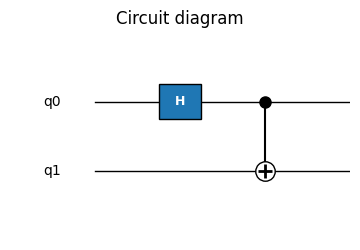

Statevector: [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
Probabilities: {'00': np.float64(0.5), '01': np.float64(0.0), '10': np.float64(0.0), '11': np.float64(0.5)}


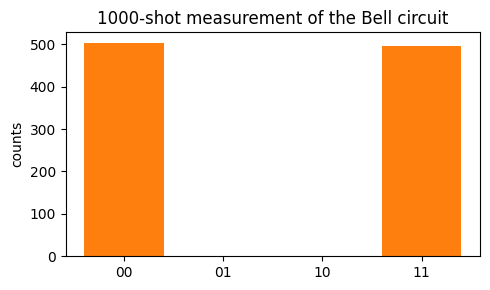

{'00': 503, '01': 0, '10': 0, '11': 497}

Only '00' and '11' ever occur, in a roughly 50/50 split -- the hallmark of |Phi+> entanglement:
the two qubits' outcomes are perfectly correlated despite each one, alone, being maximally random.


In [16]:

# Rebuild the Bell circuit using the simulator, draw it, and sample measurement outcomes
qc = QuantumCircuit(2)
qc.h(0).cnot(0, 1)
qc.draw()

print("Statevector:", qc.state.round(3))
print("Probabilities:", dict(zip(['00','01','10','11'], qc.probs().round(3))))

counts = qc.sample(shots=1000)
plt.figure(figsize=(5, 3))
plt.bar(counts.keys(), counts.values(), color='tab:orange')
plt.title('1000-shot measurement of the Bell circuit')
plt.ylabel('counts')
plt.tight_layout()
plt.show()
print(counts)
print("\nOnly '00' and '11' ever occur, in a roughly 50/50 split -- the hallmark of |Phi+> entanglement:")
print("the two qubits' outcomes are perfectly correlated despite each one, alone, being maximally random.")



## 6. Summary & Looking Ahead

| Concept | Physical anchor | Circuit role |
|---|---|---|
| Hadamard $H$ | SG $z \leftrightarrow x$ basis change | creates single-qubit superposition |
| Walsh–Hadamard $H^{\otimes n}$ | $n$ parallel SG magnets | uniform superposition over $2^n$ states; opens most quantum algorithms |
| CNOT / CZ / SWAP | correlating interaction between two "particles" | creates/manipulates entanglement |
| Toffoli | reversible classical AND | universal classical logic, error-correction building block |
| Statevector simulator | — | ties gates (linear algebra) to circuits (diagrams) to measurement (Born rule) |

**Key takeaway for the FDP discussion:** a quantum circuit is entirely described by *which unitary,
on which wires, in which order* — there is no hidden classical control-flow. Entanglement is not a
separate ingredient bolted on; it is simply what happens when a superposition-creating gate is followed
by a gate that correlates two or more wires, exactly as CNOT does after $H$.

**Coming next:** the **Bell inequality / CHSH simulation notebook** builds directly on the Bell-state
circuit above, using the purity/entanglement witnesses from §4 and the sampling machinery from §5 to
demonstrate a genuine violation of local realism — followed by teleportation, superdense coding, and
GHZ-state extensions.



## 7. Exercises

Each exercise is scaffolded: incomplete parts return an obviously-wrong placeholder (e.g. `None` or an
all-zero array) so you immediately see what still needs work, rather than silently passing. Solutions
are in collapsed cells — try each exercise yourself first.

### ★ Exercise 1 — CZ from H and CNOT

Verify the identity $\text{CZ} = (I \otimes H)\,\text{CNOT}\,(I \otimes H)$ numerically.


In [17]:

def exercise_1_cz_identity():
    '''Return True iff (I⊗H) @ CNOT @ (I⊗H) equals CZ. Complete the RHS construction.'''
    IH = embed_1q_gate(H, target=1, n_qubits=2)   # H on qubit 1 (the target of CNOT)
    # TODO: build the right-hand side of the identity below (currently a placeholder zero matrix,
    # which will obviously fail the check -- that's the point of the scaffold).
    rhs = np.zeros((4, 4), dtype=complex)
    return np.allclose(rhs, CZ), rhs

ok, rhs = exercise_1_cz_identity()
print("Identity verified?", ok)


Identity verified? False



<details>
<summary>★ Solution 1 (click to expand)</summary>

```python
def exercise_1_cz_identity():
    IH = embed_1q_gate(H, target=1, n_qubits=2)
    rhs = IH @ CNOT @ IH
    return np.allclose(rhs, CZ), rhs

ok, rhs = exercise_1_cz_identity()
print(ok)   # True
```
Physically: conjugating the CNOT's target by Hadamards rotates the "flip" into a "phase-flip",
turning a bit-flip-on-target gate into a phase-only gate that is symmetric between the two qubits.
</details>



### ★★ Exercise 2 — SWAP from three CNOTs

Verify that $\text{SWAP} = \text{CNOT}_{0\to1}\,\text{CNOT}_{1\to0}\,\text{CNOT}_{0\to1}$
(three CNOTs with alternating control/target implement a full SWAP).


In [18]:

def exercise_2_swap_from_cnots():
    '''Return True iff three alternating CNOTs equal SWAP. Fill in the missing gate below
    (currently identity, which will NOT reproduce SWAP -- fix it).'''
    CNOT_01 = CNOT                                          # control=0, target=1 (native form)
    CNOT_10 = embed_2q_gate(CNOT, control=1, target=0, n_qubits=2)
    # TODO: replace I2x2 placeholder with the correct third CNOT
    third_gate = np.eye(4, dtype=complex)
    combo = CNOT_01 @ third_gate @ CNOT_01
    return np.allclose(combo, SWAP), combo

ok, combo = exercise_2_swap_from_cnots()
print("SWAP identity verified?", ok)


SWAP identity verified? False



<details>
<summary>★★ Solution 2 (click to expand)</summary>

```python
def exercise_2_swap_from_cnots():
    CNOT_01 = CNOT
    CNOT_10 = embed_2q_gate(CNOT, control=1, target=0, n_qubits=2)
    combo = CNOT_01 @ CNOT_10 @ CNOT_01
    return np.allclose(combo, SWAP), combo

ok, combo = exercise_2_swap_from_cnots()
print(ok)   # True
```
</details>



### ★★★ Exercise 3 — W state and its entanglement structure

The **W state** $|W\rangle = \frac{1}{\sqrt3}(|100\rangle + |010\rangle + |001\rangle)$ is a genuinely
3-qubit entangled state, inequivalent to GHZ under local operations (a fact used later when discussing
entanglement classes). Build $|W\rangle$ using only single-qubit rotations and CNOTs, then verify that
tracing out *any one* qubit leaves the remaining two in a **mixed but non-maximally-entangled** state
(unlike GHZ, whose reduced two-qubit state is exactly separable).

*Hint:* one construction uses a sequence of controlled rotations with angles
$\theta_k = 2\arccos(1/\sqrt{n-k+1})$ cascading down the register; the scaffold below sets up the target
state and a purity-check harness for you to complete.


In [19]:

def exercise_3_w_state():
    '''Build the 3-qubit W state via a gate sequence of your own construction.
    Currently returns the |000> state as a placeholder -- replace `psi` with a real circuit.'''
    target = (1 / np.sqrt(3)) * (ket('100') + ket('010') + ket('001'))

    # TODO: replace this line with an actual gate sequence (H/RY-style single-qubit rotations
    # plus CNOTs) acting on ket('000'), so that `psi` matches `target` up to global phase.
    psi = ket('000')

    fidelity = np.abs(np.vdot(target, psi)) ** 2
    return psi, target, fidelity

psi, target, fidelity = exercise_3_w_state()
print("Fidelity to the true W state (1.0 = success):", round(fidelity, 3))


Fidelity to the true W state (1.0 = success): 0.0



<details>
<summary>★★★ Solution 3 (click to expand)</summary>

```python
def ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)

def controlled_ry_of3(theta, control, target, n_qubits=3):
    G = np.eye(2, dtype=complex)
    Ry = ry(theta)
    gate4 = np.block([[G, np.zeros((2, 2))], [np.zeros((2, 2)), Ry]])  # acts on {|c t>}, c ordered first
    return embed_2q_gate(gate4, control, target, n_qubits)

def exercise_3_w_state():
    target = (1 / np.sqrt(3)) * (ket('100') + ket('010') + ket('001'))

    psi = ket('000')
    psi = embed_1q_gate(ry(2 * np.arccos(1 / np.sqrt(3))), target=0, n_qubits=3) @ psi
    psi = controlled_ry_of3(2 * np.arccos(1 / np.sqrt(2)), control=0, target=1, n_qubits=3) @ psi
    psi = embed_2q_gate(CNOT, control=1, target=2, n_qubits=3) @ psi
    psi = embed_2q_gate(CNOT, control=0, target=1, n_qubits=3) @ psi
    psi = embed_1q_gate(X, target=0, n_qubits=3) @ psi

    fidelity = np.abs(np.vdot(target, psi)) ** 2
    return psi, target, fidelity

psi, target, fidelity = exercise_3_w_state()
print(round(fidelity, 3))   # should be very close to 1.0
```

Once you have `psi`, use the Notebook-4 style partial-trace tools to check that the reduced two-qubit
state (tracing out one wire of the W state) is entangled but has *different* eigenvalue structure than
the GHZ reduced state — GHZ's reduced two-qubit state is exactly separable (purity path collapses to a
classical mixture), while W's retains partial entanglement. This is the standard textbook distinction
between the GHZ and W entanglement classes.
</details>

---

*End of notebook. Reuse `QuantumCircuit`, `embed_1q_gate`, `embed_2q_gate`, `walsh_hadamard`, and
`reduced_density_matrix` unchanged in the upcoming Bell/CHSH notebook.*
